In [ ]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("aryashah2k/soybean-seedsclassification-dataset")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

100%|██████████| 610M/610M [00:07<00:00, 88.0MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/aryashah2k/soybean-seedsclassification-dataset/versions/1
Contents of base_path (/root/.cache/kagglehub/datasets/aryashah2k/soybean-seedsclassification-dataset/versions):
['1']
Contents of path (/root/.cache/kagglehub/datasets/aryashah2k/soybean-seedsclassification-dataset/versions/1):
['Spotted soybeans', 'Intact soybeans', 'Immature soybeans', 'Skin-damaged soybeans', 'Broken soybeans']


In [ ]:
import os

# Use 'path' directly as classes are located here
data_path = path

# List soybean class directories
if os.path.exists(data_path):
    classes = [d for d in os.listdir(data_path) if os.path.isdir(os.path.join(data_path, d))]
    print(f"Soybean classes found: {classes}")
else:
    print(f"Path not found: {data_path}")

Soybean classes found: ['Spotted soybeans', 'Intact soybeans', 'Immature soybeans', 'Skin-damaged soybeans', 'Broken soybeans']



--- Displaying Sample Images from Dataset (/root/.cache/kagglehub/datasets/aryashah2k/soybean-seedsclassification-dataset/versions/1) ---
Found 5513 images. Displaying 6 sample images:


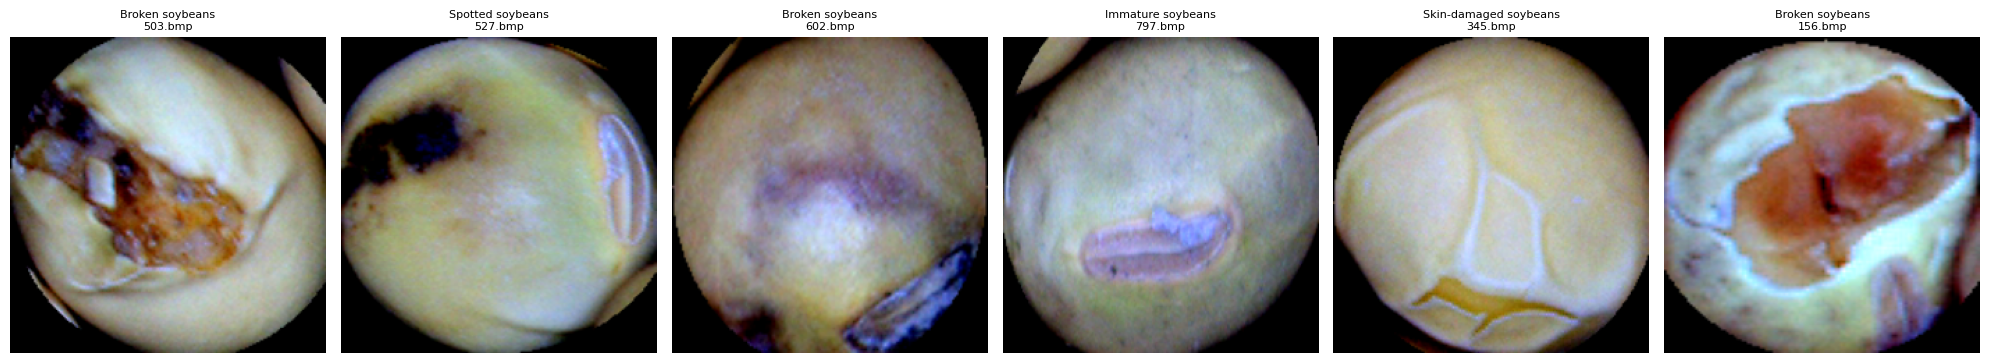

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

def display_sample_images(dataset_path, num_samples=6):
    image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp')
    all_image_paths = []

    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(image_extensions):
                all_image_paths.append(os.path.join(root, file))

    if not all_image_paths:
        print(f"No images found in {dataset_path}.")
        return

    print(f"Found {len(all_image_paths)} images. Displaying {min(num_samples, len(all_image_paths))} sample images:")

    samples_to_display = random.sample(all_image_paths, min(len(all_image_paths), num_samples))

    fig, axes = plt.subplots(1, len(samples_to_display), figsize=(20, 5))
    if len(samples_to_display) == 1:
        axes = [axes]

    for i, img_path in enumerate(samples_to_display):
        try:
            img = Image.open(img_path)
            axes[i].imshow(img)
            # Get class name from parent directory name
            label = os.path.basename(os.path.dirname(img_path))
            axes[i].set_title(f"{label}\n{os.path.basename(img_path)}", fontsize=8)
            axes[i].axis('off')
        except Exception as e:
            print(f"Error loading {img_path}: {e}")

    plt.tight_layout()
    plt.show()

# Use the correct path identified in the previous cell
data_path = path
print(f"\n--- Displaying Sample Images from Dataset ({data_path}) ---")
display_sample_images(data_path)

In [ ]:
!pip install split-folders

In [ ]:
import splitfolders

# Define the output folder
output_folder = "soybean_split"

# Split with a ratio of 0.8 for train and 0.2 for val (test)
# seed=1337 ensures reproducibility
splitfolders.ratio(data_path, output=output_folder, seed=1337, ratio=(.8, .2), group_prefix=None, move=False)

print(f"Dataset successfully split! Check the '{output_folder}' directory.")

Copying files: 5513 files [00:02, 2002.39 files/s]

Dataset successfully split! Check the 'soybean_split' directory.


In [ ]:
# Verify the split results
for split in ['train', 'val']:
    print(f"\n--- {split.upper()} set ---")
    split_path = os.path.join(output_folder, split)
    for class_name in os.listdir(split_path):
        count = len(os.listdir(os.path.join(split_path, class_name)))
        print(f"{class_name}: {count} images")


--- TRAIN set ---
Spotted soybeans: 846 images
Intact soybeans: 960 images
Immature soybeans: 900 images
Skin-damaged soybeans: 901 images
Broken soybeans: 801 images

--- VAL set ---
Spotted soybeans: 212 images
Intact soybeans: 241 images
Immature soybeans: 225 images
Skin-damaged soybeans: 226 images
Broken soybeans: 201 images


In [ ]:
import torch

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

Using device: cpu


In [ ]:
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

# Data transformations
transform = transforms.Compose([
    transforms.Resize((227, 227)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load datasets
train_dataset = datasets.ImageFolder(root='soybean_split/train', transform=transform)
val_dataset = datasets.ImageFolder(root='soybean_split/val', transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Define AlexNet Architecture
class AlexNet(nn.Module):
    def __init__(self, num_classes=5):
        super(AlexNet, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=11, stride=4, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(64, 192, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )
        self.avgpool = nn.AdaptiveAvgPool2d((6, 6))
        self.classifier = nn.Sequential(
            nn.Dropout(),
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

model = AlexNet(num_classes=len(train_dataset.classes)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

In [ ]:
num_epochs = 10
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(num_epochs):
    model.train()
    running_loss, correct = 0.0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = correct / len(train_loader.dataset)
    history['train_loss'].append(epoch_loss)
    history['train_acc'].append(epoch_acc)

    model.eval()
    val_loss, val_correct = 0.0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()

    v_loss = val_loss / len(val_loader.dataset)
    v_acc = val_correct / len(val_loader.dataset)
    history['val_loss'].append(v_loss)
    history['val_acc'].append(v_acc)

    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.4f} | Val Loss: {v_loss:.4f}, Val Acc: {v_acc:.4f}")

Epoch 1/10 - Loss: 1.3435, Acc: 0.3863 | Val Loss: 1.2026, Val Acc: 0.4163
Epoch 2/10 - Loss: 0.9693, Acc: 0.6177 | Val Loss: 0.7873, Val Acc: 0.6842
Epoch 3/10 - Loss: 0.7137, Acc: 0.7205 | Val Loss: 0.6356, Val Acc: 0.7493
Epoch 4/10 - Loss: 0.6001, Acc: 0.7738 | Val Loss: 0.5508, Val Acc: 0.7864
Epoch 5/10 - Loss: 0.5293, Acc: 0.7926 | Val Loss: 0.6254, Val Acc: 0.7729
Epoch 6/10 - Loss: 0.5217, Acc: 0.7995 | Val Loss: 0.4898, Val Acc: 0.8054
Epoch 7/10 - Loss: 0.4377, Acc: 0.8285 | Val Loss: 0.5036, Val Acc: 0.8063
Epoch 8/10 - Loss: 0.4219, Acc: 0.8401 | Val Loss: 0.4954, Val Acc: 0.8109
Epoch 9/10 - Loss: 0.3592, Acc: 0.8584 | Val Loss: 0.4200, Val Acc: 0.8416
Epoch 10/10 - Loss: 0.3423, Acc: 0.8723 | Val Loss: 0.4283, Val Acc: 0.8407


In [ ]:
print("--- Training Summary ---")
final_train_acc = history['train_acc'][-1]
final_val_acc = history['val_acc'][-1]
print(f"Final Training Accuracy: {final_train_acc*100:.2f}%")
print(f"Final Validation Accuracy: {final_val_acc*100:.2f}%")

--- Training Summary ---
Final Training Accuracy: 87.23%
Final Validation Accuracy: 84.07%


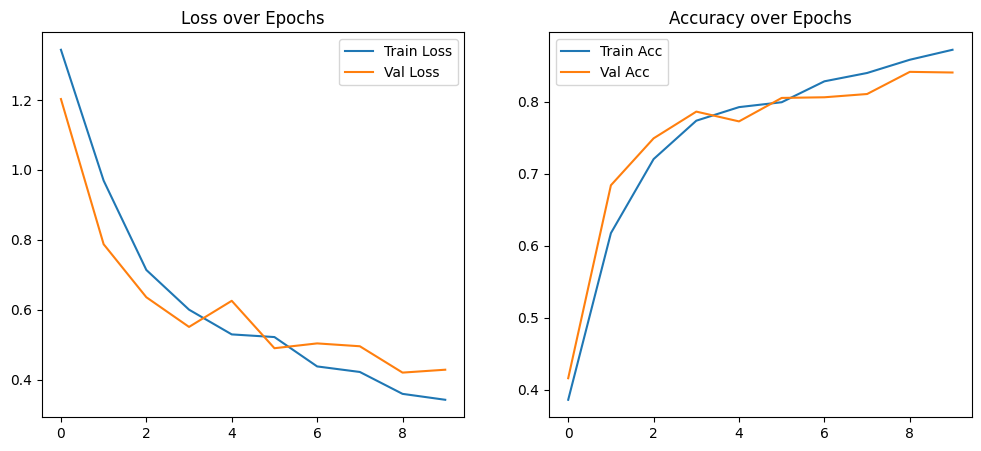

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.title('Accuracy over Epochs')
plt.legend()

plt.show()